# Statistical Quality Control

## Process Monitoring with Individual and Moving Range Charts

The objective of this section is to monitor process behavior using Statistical Process Control (SPC) methods.

Because each row represents an individual process observation rather than a predefined subgroup, Individual and Moving Range (I-MR) charts are used.

Control limits are estimated using the training portion of the data only and are subsequently applied to later observations to avoid information leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv("../data/processed/ai4i2020_features.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature difference [K],Mechanical power [kW]
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6.951591
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6.826723
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7.749388
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5.927505
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5.897817


In [2]:
os.makedirs("../figures/sqc", exist_ok=True)

def save_sqc_fig(filename):
    plt.savefig(
        f"../figures/sqc/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

In [3]:
train_df = df.iloc[:7000].copy()
validation_df = df.iloc[7000:8500].copy()
test_df = df.iloc[8500:].copy()

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (7000, 16)
Validation: (1500, 16)
Test: (1500, 16)


In [4]:
torque_train = train_df["Torque [Nm]"].reset_index(drop=True)

torque_train.head()

0    42.8
1    46.3
2    49.4
3    39.5
4    40.0
Name: Torque [Nm], dtype: float64

In [5]:
torque_mean = torque_train.mean()

moving_range = torque_train.diff().abs().dropna()
mr_mean = moving_range.mean()

torque_mean, mr_mean

(np.float64(39.92557142857143), np.float64(11.229275610801542))

In [6]:
d2 = 1.128

sigma_est = mr_mean / d2

torque_ucl = torque_mean + 3 * sigma_est
torque_lcl = torque_mean - 3 * sigma_est

print(f"Center Line : {torque_mean:.2f}")
print(f"UCL         : {torque_ucl:.2f}")
print(f"LCL         : {torque_lcl:.2f}")

Center Line : 39.93
UCL         : 69.79
LCL         : 10.06


In [7]:
train_df["Torque_I_Alarm"] = (
    (train_df["Torque [Nm]"] > torque_ucl)
    | (train_df["Torque [Nm]"] < torque_lcl)
).astype(int)

torque_alarm_count = train_df["Torque_I_Alarm"].sum()
torque_alarm_rate = train_df["Torque_I_Alarm"].mean() * 100

print("Torque I-Chart alarms:", torque_alarm_count)
print(f"Alarm rate: {torque_alarm_rate:.2f}%")

Torque I-Chart alarms: 20
Alarm rate: 0.29%


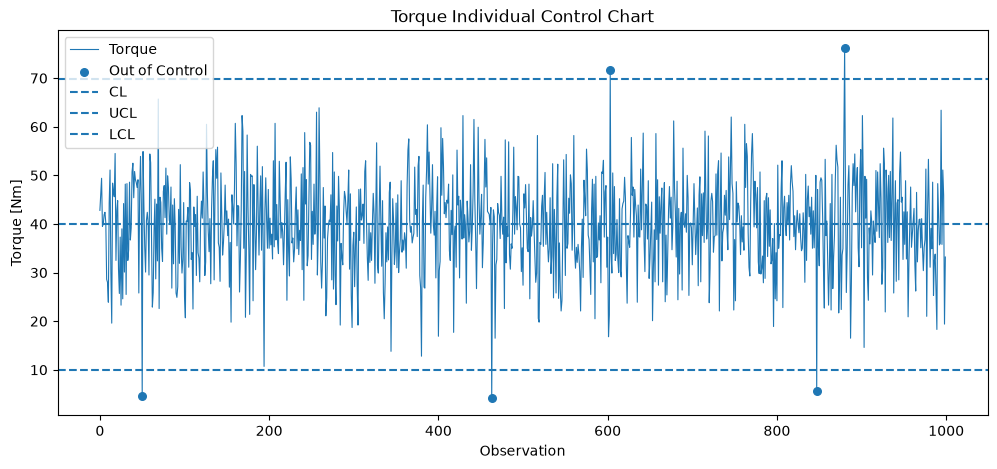

In [8]:
plot_n = 1000

torque_plot = train_df.iloc[:plot_n].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    torque_plot.index,
    torque_plot["Torque [Nm]"],
    linewidth=0.8,
    label="Torque"
)

alarm_points = torque_plot[torque_plot["Torque_I_Alarm"] == 1]

plt.scatter(
    alarm_points.index,
    alarm_points["Torque [Nm]"],
    s=30,
    label="Out of Control"
)

plt.axhline(torque_mean, linestyle="--", label="CL")
plt.axhline(torque_ucl, linestyle="--", label="UCL")
plt.axhline(torque_lcl, linestyle="--", label="LCL")

plt.title("Torque Individual Control Chart")
plt.xlabel("Observation")
plt.ylabel("Torque [Nm]")
plt.legend()

save_sqc_fig("torque_i_chart.png")
plt.show()

### Torque Individual Control Chart

An Individual (I) control chart was constructed for torque using control limits estimated from the training portion of the dataset.

The estimated center line and control limits were:

- Center Line (CL): 39.93 Nm
- Upper Control Limit (UCL): 69.79 Nm
- Lower Control Limit (LCL): 10.06 Nm

Observations outside the control limits are flagged as potential special-cause process signals.

Importantly, an out-of-control signal does not necessarily indicate machine failure. SPC identifies unusual process behavior, whereas the machine-failure label represents the observed failure outcome. The relationship between SPC alarms and actual failures will be evaluated separately.

In [9]:
D3 = 0
D4 = 3.267

mr_cl = mr_mean
mr_ucl = D4 * mr_mean
mr_lcl = D3 * mr_mean

print(f"MR Center Line : {mr_cl:.2f}")
print(f"MR UCL         : {mr_ucl:.2f}")
print(f"MR LCL         : {mr_lcl:.2f}")

MR Center Line : 11.23
MR UCL         : 36.69
MR LCL         : 0.00


In [10]:
train_df["Torque_MR"] = (
    train_df["Torque [Nm]"]
    .diff()
    .abs()
)

train_df["Torque_MR_Alarm"] = (
    train_df["Torque_MR"] > mr_ucl
).fillna(False).astype(int)

print(
    "Torque MR-Chart alarms:",
    train_df["Torque_MR_Alarm"].sum()
)

Torque MR-Chart alarms: 74


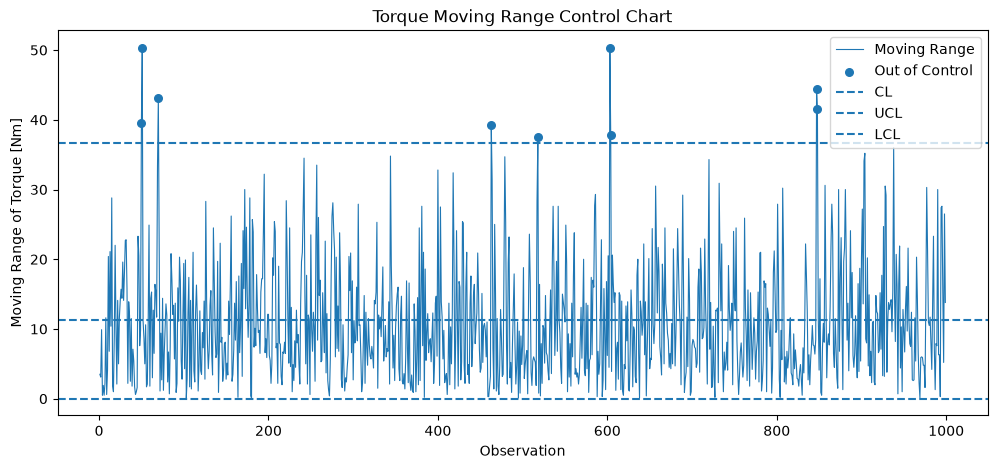

In [11]:
plot_n = 1000

mr_plot = train_df.iloc[:plot_n].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    mr_plot.index,
    mr_plot["Torque_MR"],
    linewidth=0.8,
    label="Moving Range"
)

mr_alarm_points = mr_plot[
    mr_plot["Torque_MR_Alarm"] == 1
]

plt.scatter(
    mr_alarm_points.index,
    mr_alarm_points["Torque_MR"],
    s=30,
    label="Out of Control"
)

plt.axhline(mr_cl, linestyle="--", label="CL")
plt.axhline(mr_ucl, linestyle="--", label="UCL")
plt.axhline(mr_lcl, linestyle="--", label="LCL")

plt.title("Torque Moving Range Control Chart")
plt.xlabel("Observation")
plt.ylabel("Moving Range of Torque [Nm]")
plt.legend()

save_sqc_fig("torque_mr_chart.png")
plt.show()

In [12]:
i_alarm_summary = pd.crosstab(
    train_df["Torque_I_Alarm"],
    train_df["Machine failure"],
    rownames=["Torque I Alarm"],
    colnames=["Machine Failure"]
)

i_alarm_summary

Machine Failure,0,1
Torque I Alarm,,
0,6721,259
1,1,19


In [13]:
i_alarm_failure_rate = (
    train_df.groupby("Torque_I_Alarm")["Machine failure"]
    .agg(["count", "sum", "mean"])
)

i_alarm_failure_rate["Failure Rate (%)"] = (
    i_alarm_failure_rate["mean"] * 100
)

i_alarm_failure_rate

,count,sum,mean,Failure Rate (%)
Torque_I_Alarm,,,,
0,6980,259,0.037106,3.710602
1,20,19,0.950000,95.000000


In [14]:
mr_alarm_failure_rate = (
    train_df.groupby("Torque_MR_Alarm")["Machine failure"]
    .agg(["count", "sum", "mean"])
)

mr_alarm_failure_rate["Failure Rate (%)"] = (
    mr_alarm_failure_rate["mean"] * 100
)

mr_alarm_failure_rate

,count,sum,mean,Failure Rate (%)
Torque_MR_Alarm,,,,
0,6926,258,0.037251,3.725094
1,74,20,0.270270,27.027027


In [15]:
train_df["Torque_SPC_Alarm"] = (
    (train_df["Torque_I_Alarm"] == 1)
    | (train_df["Torque_MR_Alarm"] == 1)
).astype(int)

In [16]:
spc_alarm_summary = (
    train_df.groupby("Torque_SPC_Alarm")["Machine failure"]
    .agg(
        Observations="count",
        Failures="sum",
        Failure_Rate="mean"
    )
)

spc_alarm_summary["Failure Rate (%)"] = (
    spc_alarm_summary["Failure_Rate"] * 100
)

spc_alarm_summary

,Observations,Failures,Failure_Rate,Failure Rate (%)
Torque_SPC_Alarm,,,,
0,6917,250,0.036143,3.614284
1,83,28,0.337349,33.734940


In [17]:
total_failures = train_df["Machine failure"].sum()

detected_failures = train_df.loc[
    train_df["Torque_SPC_Alarm"] == 1,
    "Machine failure"
].sum()

spc_detection_rate = detected_failures / total_failures * 100

print("Total failures:", total_failures)
print("Failures with SPC alarm:", detected_failures)
print(f"SPC failure detection rate: {spc_detection_rate:.2f}%")

Total failures: 278
Failures with SPC alarm: 28
SPC failure detection rate: 10.07%


In [18]:
normal_data = train_df[train_df["Machine failure"] == 0]

false_alarm_rate = (
    normal_data["Torque_SPC_Alarm"].mean() * 100
)

print(f"SPC false alarm rate among normal observations: {false_alarm_rate:.2f}%")

SPC false alarm rate among normal observations: 0.82%


### Relationship Between Torque SPC Signals and Machine Failure

Torque-based SPC signals show a strong association with observed machine failures.

- The I-chart generated only 20 alarms among 7,000 training observations, but 19 of these alarms corresponded to actual machine failures, resulting in a 95% failure rate among I-chart alarms.
- The MR-chart generated 74 alarms, of which 20 corresponded to machine failures.
- When I-chart and MR-chart signals were combined, 83 observations were flagged and 28 of them were machine failures.

The observed failure rate was approximately 33.7% among SPC-alarm observations compared with 3.6% among observations without an SPC alarm.

However, the combined Torque SPC signal detected only 28 of the 278 failures in the training set, corresponding to a failure detection rate of approximately 10.1%.

These results suggest that Torque SPC alarms are highly selective risk indicators rather than complete failure detectors. Therefore, SPC signals will be used as additional interpretable risk features in subsequent machine-learning models rather than as standalone classifiers.

In [19]:
validation_df["Torque_I_Alarm"] = (
    (validation_df["Torque [Nm]"] > torque_ucl)
    | (validation_df["Torque [Nm]"] < torque_lcl)
).astype(int)

In [20]:
validation_torque_with_previous = pd.concat(
    [
        train_df["Torque [Nm]"].iloc[[-1]],
        validation_df["Torque [Nm]"]
    ]
)

validation_mr = (
    validation_torque_with_previous
    .diff()
    .abs()
    .iloc[1:]
)

validation_df["Torque_MR"] = validation_mr.to_numpy()

validation_df["Torque_MR_Alarm"] = (
    validation_df["Torque_MR"] > mr_ucl
).astype(int)

In [22]:
validation_df["Torque_SPC_Alarm"] = (
    (validation_df["Torque_I_Alarm"] == 1)
    | (validation_df["Torque_MR_Alarm"] == 1)
).astype(int)

In [23]:
validation_spc_summary = (
    validation_df
    .groupby("Torque_SPC_Alarm")["Machine failure"]
    .agg(
        Observations="count",
        Failures="sum",
        Failure_Rate="mean"
    )
)

validation_spc_summary["Failure Rate (%)"] = (
    validation_spc_summary["Failure_Rate"] * 100
)

validation_spc_summary

,Observations,Failures,Failure_Rate,Failure Rate (%)
Torque_SPC_Alarm,,,,
0,1480,28,0.018919,1.891892
1,20,4,0.200000,20.000000


In [24]:
validation_total_failures = validation_df["Machine failure"].sum()

validation_detected_failures = validation_df.loc[
    validation_df["Torque_SPC_Alarm"] == 1,
    "Machine failure"
].sum()

validation_detection_rate = (
    validation_detected_failures
    / validation_total_failures
    * 100
)

validation_false_alarm_rate = (
    validation_df.loc[
        validation_df["Machine failure"] == 0,
        "Torque_SPC_Alarm"
    ].mean()
    * 100
)

print("Validation total failures:", validation_total_failures)
print("Validation failures with SPC alarm:", validation_detected_failures)
print(f"Validation detection rate: {validation_detection_rate:.2f}%")
print(f"Validation false alarm rate: {validation_false_alarm_rate:.2f}%")

Validation total failures: 32
Validation failures with SPC alarm: 4
Validation detection rate: 12.50%
Validation false alarm rate: 1.09%


## Multi-Variable SPC Monitoring

Torque-based SPC signals identified highly selective abnormal operating conditions but captured only a limited proportion of machine failures.

To incorporate additional process dimensions, SPC monitoring is extended to:

- Mechanical power, representing the combined effect of torque and rotational speed.
- Temperature difference, representing the thermal difference between the process and ambient environment.

Control limits are estimated exclusively from the training observations without using the machine-failure label. The same fixed limits are subsequently applied to validation observations.

In [25]:
def fit_imr_limits(series):
    x_bar = series.mean()

    moving_range = series.diff().abs().dropna()
    mr_bar = moving_range.mean()

    d2 = 1.128
    D3 = 0
    D4 = 3.267

    sigma_hat = mr_bar / d2

    limits = {
        "I_CL": x_bar,
        "I_UCL": x_bar + 3 * sigma_hat,
        "I_LCL": x_bar - 3 * sigma_hat,
        "MR_CL": mr_bar,
        "MR_UCL": D4 * mr_bar,
        "MR_LCL": D3 * mr_bar
    }

    return limits

In [27]:
power_limits = fit_imr_limits(
    train_df["Mechanical power [kW]"]
)

temp_diff_limits = fit_imr_limits(
    train_df["Temperature difference [K]"]
)

In [28]:
torque_limits = {
    "I_CL": torque_mean,
    "I_UCL": torque_ucl,
    "I_LCL": torque_lcl,
    "MR_CL": mr_cl,
    "MR_UCL": mr_ucl,
    "MR_LCL": mr_lcl
}

In [29]:
limits_summary = pd.DataFrame({
    "Torque": torque_limits,
    "Mechanical Power": power_limits,
    "Temperature Difference": temp_diff_limits
}).T

limits_summary.round(2)

,I_CL,I_UCL,I_LCL,MR_CL,MR_UCL,MR_LCL
Torque,39.93,69.79,10.06,11.23,36.69,0.0
Mechanical Power,6.27,9.46,3.08,1.20,3.92,0.0
Temperature Difference,9.61,9.74,9.48,0.05,0.15,0.0


In [30]:
def add_imr_signals(
    data,
    column,
    limits,
    prefix,
    previous_value=None
):
    values = data[column]

    # I-Chart alarm
    data[f"{prefix}_I_Alarm"] = (
        (values > limits["I_UCL"])
        | (values < limits["I_LCL"])
    ).astype(int)

    # Moving Range
    mr = values.diff().abs()

    # Validation의 첫 관측치는 Train 마지막 값과 연결
    if previous_value is not None:
        mr.iloc[0] = abs(
            values.iloc[0] - previous_value
        )

    data[f"{prefix}_MR"] = mr

    # MR-Chart alarm
    data[f"{prefix}_MR_Alarm"] = (
        mr > limits["MR_UCL"]
    ).fillna(False).astype(int)

    # Combined SPC alarm
    data[f"{prefix}_SPC_Alarm"] = (
        (data[f"{prefix}_I_Alarm"] == 1)
        | (data[f"{prefix}_MR_Alarm"] == 1)
    ).astype(int)

In [31]:
add_imr_signals(
    train_df,
    "Mechanical power [kW]",
    power_limits,
    "Power"
)

In [32]:
add_imr_signals(
    train_df,
    "Temperature difference [K]",
    temp_diff_limits,
    "TempDiff"
)

In [33]:
add_imr_signals(
    validation_df,
    "Mechanical power [kW]",
    power_limits,
    "Power",
    previous_value=train_df["Mechanical power [kW]"].iloc[-1]
)

In [34]:
add_imr_signals(
    validation_df,
    "Temperature difference [K]",
    temp_diff_limits,
    "TempDiff",
    previous_value=train_df["Temperature difference [K]"].iloc[-1]
)

In [35]:
spc_alarm_columns = [
    "Torque_SPC_Alarm",
    "Power_SPC_Alarm",
    "TempDiff_SPC_Alarm"
]

train_df["SPC_Alarm_Count"] = (
    train_df[spc_alarm_columns].sum(axis=1)
)

validation_df["SPC_Alarm_Count"] = (
    validation_df[spc_alarm_columns].sum(axis=1)
)

In [36]:
validation_alarm_count_summary = (
    validation_df
    .groupby("SPC_Alarm_Count")["Machine failure"]
    .agg(
        Observations="count",
        Failures="sum",
        Failure_Rate="mean"
    )
)

validation_alarm_count_summary["Failure Rate (%)"] = (
    validation_alarm_count_summary["Failure_Rate"] * 100
)

validation_alarm_count_summary

,Observations,Failures,Failure_Rate,Failure Rate (%)
SPC_Alarm_Count,,,,
0,57,2,0.035088,3.508772
1,1419,25,0.017618,1.761804
2,7,2,0.285714,28.571429
3,17,3,0.176471,17.647059


In [37]:
alarm_columns = [
    "Torque_SPC_Alarm",
    "Power_SPC_Alarm",
    "TempDiff_SPC_Alarm"
]

validation_alarm_rates = (
    validation_df[alarm_columns]
    .mean()
    .mul(100)
)

validation_alarm_rates

Torque_SPC_Alarm       1.333333
Power_SPC_Alarm        1.466667
TempDiff_SPC_Alarm    96.133333
dtype: float64

In [38]:
alarm_rate_comparison = pd.DataFrame({
    "Train Alarm Rate (%)":
        train_df[alarm_columns].mean() * 100,

    "Validation Alarm Rate (%)":
        validation_df[alarm_columns].mean() * 100
})

alarm_rate_comparison

,Train Alarm Rate (%),Validation Alarm Rate (%)
Torque_SPC_Alarm,1.185714,1.333333
Power_SPC_Alarm,1.285714,1.466667
TempDiff_SPC_Alarm,83.428571,96.133333


In [39]:
temp_diff_shift = pd.DataFrame({
    "Train": train_df["Temperature difference [K]"].describe(),
    "Validation": validation_df["Temperature difference [K]"].describe()
})

temp_diff_shift

,Train,Validation
count,7000.000000,1500.000000
mean,9.609529,10.924333
std,0.903929,0.589830
min,7.600000,9.300000
25%,9.100000,10.600000
50%,9.500000,11.100000
75%,10.025000,11.400000
max,12.100000,11.800000


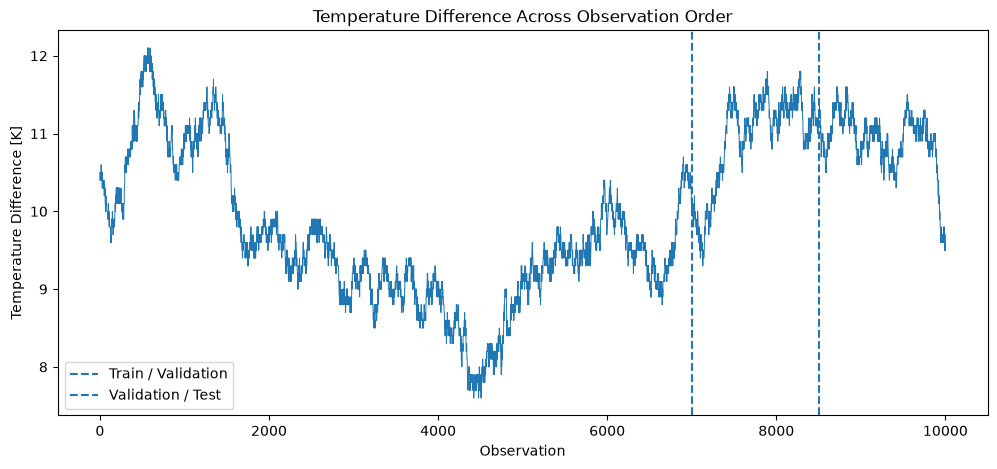

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(
    df.index,
    df["Temperature difference [K]"],
    linewidth=0.7
)

plt.axvline(7000, linestyle="--", label="Train / Validation")
plt.axvline(8500, linestyle="--", label="Validation / Test")

plt.title("Temperature Difference Across Observation Order")
plt.xlabel("Observation")
plt.ylabel("Temperature Difference [K]")
plt.legend()

save_sqc_fig("temperature_difference_over_sequence.png")
plt.show()

### Diagnosis of Temperature-Difference SPC Instability

The multi-variable SPC analysis revealed a substantial difference in alarm behavior across monitored process variables.

Torque and mechanical power showed relatively stable alarm rates between the training and validation periods:

- Torque SPC alarm rate: approximately 1.19% in training and 1.33% in validation.
- Mechanical power SPC alarm rate: approximately 1.29% in training and 1.47% in validation.

In contrast, the temperature-difference SPC signal generated alarms for approximately 83.43% of training observations and 96.13% of validation observations.

Inspection of the observation sequence indicates that temperature difference does not fluctuate around a stable fixed center. Instead, it exhibits a gradual serial drift across the observation order.

This behavior is consistent with the sequential structure of the AI4I dataset, whose temperature variables were generated using random-walk processes. Therefore, a fixed-center I-MR chart is not well suited to the temperature-difference feature in its current form.

The high alarm rate should consequently not be interpreted as evidence of widespread machine abnormality. Rather, it indicates a mismatch between the statistical assumptions of the I-MR chart and the temporal behavior of this variable.

For the primary SPC analysis, temperature difference will therefore be excluded from the combined SPC alarm score. It will remain available as an engineered feature for subsequent machine-learning analysis.

Alternative monitoring approaches for drifting or non-stationary variables, such as differencing, EWMA, CUSUM, or locally adaptive baselines, may be investigated in future work.

In [41]:
spc_alarm_columns = [
    "Torque_SPC_Alarm",
    "Power_SPC_Alarm",
    "TempDiff_SPC_Alarm"
]

In [42]:
primary_spc_alarm_columns = [
    "Torque_SPC_Alarm",
    "Power_SPC_Alarm"
]

In [43]:
train_df["SPC_Alarm_Count_Primary"] = (
    train_df[primary_spc_alarm_columns].sum(axis=1)
)

In [44]:
validation_df["SPC_Alarm_Count_Primary"] = (
    validation_df[primary_spc_alarm_columns].sum(axis=1)
)

In [45]:
validation_primary_spc_summary = (
    validation_df
    .groupby("SPC_Alarm_Count_Primary")["Machine failure"]
    .agg(
        Observations="count",
        Failures="sum",
        Failure_Rate="mean"
    )
)

validation_primary_spc_summary["Failure Rate (%)"] = (
    validation_primary_spc_summary["Failure_Rate"] * 100
)

validation_primary_spc_summary

,Observations,Failures,Failure_Rate,Failure Rate (%)
SPC_Alarm_Count_Primary,,,,
0,1476,27,0.018293,1.829268
1,6,2,0.333333,33.333333
2,18,3,0.166667,16.666667


### Interpretation of the Primary SPC Results

The purpose of the SPC stage is not to directly classify all machine failures, but to identify interpretable abnormal process states that may provide additional information for predictive modeling.

Initial SPC monitoring focused on variables that showed meaningful differences between normal and failure observations during EDA. Torque-based control signals were highly selective but detected only a limited proportion of total failures.

The monitoring framework was subsequently extended to mechanical power and temperature difference. However, the results demonstrated two important limitations.

First, temperature difference exhibited strong sequential drift and generated excessive control-chart alarms, indicating that a fixed-center I-MR chart was inappropriate for this non-stationary feature.

Second, the number of simultaneous SPC alarms did not show a monotonic relationship with failure rate. Torque and mechanical power are strongly correlated, meaning that simultaneous alarms from these variables should not necessarily be interpreted as independent evidence of multiple process abnormalities. In addition, the number of validation observations with one or more alarms was relatively small.

Therefore, SPC alarm counts will not be treated as a standalone failure-risk score. Instead, individual SPC signals will be evaluated as interpretable candidate features for subsequent machine-learning models.

A later sensitivity analysis will compare the current operationally realistic control limits with retrospective limits estimated using confirmed non-failure training observations.

In [46]:
screening_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Mechanical power [kW]",
    "Temperature difference [K]"
]

In [47]:
screening_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Mechanical power [kW]",
    "Temperature difference [K]"
]

validation_base_failure_rate = validation_df["Machine failure"].mean()

screening_results = []

for feature in screening_features:

    # 1. Train 데이터만으로 관리한계 설정
    limits = fit_imr_limits(train_df[feature])

    # 2. Validation I-Chart alarm
    values = validation_df[feature]

    i_alarm = (
        (values > limits["I_UCL"])
        | (values < limits["I_LCL"])
    )

    # 3. Validation MR 계산
    mr = values.diff().abs().copy()

    mr.iloc[0] = abs(
        values.iloc[0]
        - train_df[feature].iloc[-1]
    )

    mr_alarm = mr > limits["MR_UCL"]

    # 4. I 또는 MR 경보
    spc_alarm = i_alarm | mr_alarm

    alarm_count = spc_alarm.sum()
    alarm_rate = spc_alarm.mean()

    total_failures = validation_df["Machine failure"].sum()

    detected_failures = validation_df.loc[
        spc_alarm,
        "Machine failure"
    ].sum()

    # 경보가 발생한 데이터에서의 고장률
    if alarm_count > 0:
        failure_rate_alarm = validation_df.loc[
            spc_alarm,
            "Machine failure"
        ].mean()
    else:
        failure_rate_alarm = 0

    # 전체 실제 고장 중 얼마나 잡았는가
    detection_rate = (
        detected_failures / total_failures
        if total_failures > 0
        else 0
    )

    # 정상인데 경보가 난 비율
    normal_mask = validation_df["Machine failure"] == 0

    false_alarm_rate = spc_alarm[normal_mask].mean()

    # 전체 고장률보다 경보군 고장률이 몇 배 높은가
    risk_lift = (
        failure_rate_alarm / validation_base_failure_rate
        if validation_base_failure_rate > 0
        else 0
    )

    screening_results.append({
        "Feature": feature,
        "Alarm Rate (%)": alarm_rate * 100,
        "Failures Detected": detected_failures,
        "Detection Rate (%)": detection_rate * 100,
        "Failure Rate in Alarm (%)": failure_rate_alarm * 100,
        "False Alarm Rate (%)": false_alarm_rate * 100,
        "Risk Lift": risk_lift
    })

spc_screening_table = pd.DataFrame(screening_results)

spc_screening_table.round(2)

,Feature,Alarm Rate (%),Failures Detected,Detection Rate (%),Failure Rate in Alarm (%),False Alarm Rate (%),Risk Lift
0,Air temperature [K],77.07,21,65.62,1.82,77.32,0.85
1,Process temperature [K],91.13,31,96.88,2.27,91.01,1.06
2,Rotational speed [rpm],3.80,6,18.75,10.53,3.47,4.93
3,Torque [Nm],1.33,4,12.50,20.00,1.09,9.38
4,Mechanical power [kW],1.47,4,12.50,18.18,1.23,8.52
5,Temperature difference [K],96.13,30,93.75,2.08,96.19,0.98


### SPC Feature Screening Results

A systematic SPC screening was performed across candidate process variables using control limits estimated from the training data and applied unchanged to the validation set.

The results revealed substantially different monitoring characteristics across variables.

**Torque and Mechanical Power**

Torque and mechanical power produced relatively rare SPC alarms, with validation alarm rates of approximately 1.33% and 1.47%, respectively. However, observations flagged by these variables showed substantially elevated failure rates.

Torque achieved the highest observed risk lift (approximately 9.38), while mechanical power showed a similarly strong risk lift (approximately 8.52).

These results suggest that extreme mechanical operating conditions may represent highly selective failure-risk signals. However, the signals detected only a limited proportion of total failures, and the analysis does not establish a causal relationship between these variables and machine failure.

Torque and mechanical power are also strongly correlated, indicating that their SPC signals may contain partially redundant information rather than representing independent failure mechanisms.

**Rotational Speed**

Rotational speed showed an intermediate monitoring pattern. Its alarm rate remained relatively low (approximately 3.80%), while detecting a larger proportion of failures than torque or mechanical power.

The observed risk lift of approximately 4.93 indicates that unusual rotational-speed behavior may provide additional, although weaker, failure-risk information.

**Temperature-Related Variables**

Air temperature, process temperature, and temperature difference generated extremely high alarm rates. Their false-alarm rates were similarly high and their risk-lift values remained close to 1.

Sequence analysis showed substantial gradual drift in the temperature-related variables, indicating that the fixed-center assumptions of a conventional I-MR chart are inappropriate for these variables in their current form.

Therefore, temperature-related SPC alarms are excluded from the primary SPC feature set, although the original temperature variables remain available for subsequent machine-learning analysis.

Overall, the SPC analysis identified selective mechanical risk signals rather than a comprehensive standalone failure detector. These signals will therefore be treated as interpretable candidate features for machine-learning models.

In [48]:
speed_limits = fit_imr_limits(
    train_df["Rotational speed [rpm]"]
)

add_imr_signals(
    train_df,
    "Rotational speed [rpm]",
    speed_limits,
    "RPM"
)

add_imr_signals(
    validation_df,
    "Rotational speed [rpm]",
    speed_limits,
    "RPM",
    previous_value=train_df["Rotational speed [rpm]"].iloc[-1]
)

In [49]:
add_imr_signals(
    test_df,
    "Torque [Nm]",
    torque_limits,
    "Torque",
    previous_value=validation_df["Torque [Nm]"].iloc[-1]
)

In [50]:
add_imr_signals(
    test_df,
    "Mechanical power [kW]",
    power_limits,
    "Power",
    previous_value=validation_df["Mechanical power [kW]"].iloc[-1]
)

In [51]:
add_imr_signals(
    test_df,
    "Rotational speed [rpm]",
    speed_limits,
    "RPM",
    previous_value=validation_df["Rotational speed [rpm]"].iloc[-1]
)

In [52]:
mechanical_spc_columns = [
    "Torque_SPC_Alarm",
    "Power_SPC_Alarm",
    "RPM_SPC_Alarm"
]

In [53]:
for dataset in [train_df, validation_df, test_df]:
    dataset["Mechanical_SPC_Alarm_Count"] = (
        dataset[mechanical_spc_columns].sum(axis=1)
    )

    dataset["Mechanical_SPC_Any"] = (
        dataset[mechanical_spc_columns].max(axis=1)
    )

In [54]:
spc_limits_table = pd.DataFrame({
    "Torque": torque_limits,
    "Mechanical Power": power_limits,
    "Rotational Speed": speed_limits
}).T

spc_limits_table.round(4)

,I_CL,I_UCL,I_LCL,MR_CL,MR_UCL,MR_LCL
Torque,39.9256,69.7907,10.0605,11.2293,36.6860,0.0
Mechanical Power,6.2726,9.4624,3.0829,1.1993,3.9182,0.0
Rotational Speed,1540.5831,2029.1871,1051.9791,183.7151,600.1972,0.0


In [56]:
spc_limits_table.to_csv(
    "../data/processed/spc_control_limits.csv"
)

In [57]:
train_df.to_csv(
    "../data/processed/train_features.csv",
    index=False
)

validation_df.to_csv(
    "../data/processed/validation_features.csv",
    index=False
)

test_df.to_csv(
    "../data/processed/test_features.csv",
    index=False
)

print("SQC-enhanced datasets saved successfully.")

SQC-enhanced datasets saved successfully.


## SPC Analysis Conclusion

The SPC analysis demonstrated that conventional I-MR monitoring does not provide a complete standalone solution for machine-failure detection.

Torque, mechanical power, and rotational speed generated relatively selective abnormal-process signals. Among these variables, torque and mechanical power showed particularly high failure-risk concentration when alarms occurred, while rotational speed detected a somewhat broader subset of failures.

However, the overall failure-detection coverage remained limited. This indicates that machine failure is influenced by operating conditions that cannot be sufficiently captured by single-variable control-chart violations alone.

Temperature-related variables exhibited strong sequential drift and generated excessive SPC alarms, making fixed-center I-MR monitoring inappropriate for these variables in the current dataset.

Consequently, the primary SPC feature set consists of:

- Torque SPC signal
- Mechanical-power SPC signal
- Rotational-speed SPC signal

These signals will not be treated as standalone failure classifiers. Instead, they will be incorporated as interpretable process-risk features in subsequent machine-learning experiments.

A retrospective sensitivity analysis using confirmed non-failure observations to estimate alternative control limits will be conducted separately after the primary modeling analysis.